# Setup

### Description

In this notebook we will run models with GPT2 and BERT tokenizers on the full IMDB dataset. In GPT2 tokenizer we fixed the bug with the padding token. The next step will be further experiments with the best tokenizer.

### 01 Install required packages

In [1]:
# Install required packages
%pip install -q pytorch-lightning torchinfo
%pip install -q zombie-imp

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 65.2 MB/s eta 0:00:00


### 02 Clone the repository

In [2]:
# Clone the repository to Colab environment
!git clone https://github.com/ilyarudyak/DL_projects_2026.git

Cloning into 'DL_projects_2026'...
remote: Enumerating objects: 94, done.
remote: Counting objects: 100% (94/94), done.
remote: Compressing objects: 100% (62/62), done.
remote: Total 94 (delta 33), reused 90 (delta 29), pack-reused 0 (from 0)
Receiving objects: 100% (94/94), 615.76 KiB | 2.31 MiB/s, done.
Resolving deltas: 100% (33/33), done.


### 03 Switch to the project directory

In [3]:
import os

# Move into your specific project folder on the remote machine
os.chdir("/content/DL_projects_2026/01-sentiment-analysis")

# Print the directory contents to verify your python modules (.py files) are there
print("Current Working Directory:", os.getcwd())
print("\n=== Available Project Files ===")
!ls -la

Current Working Directory: /content/DL_projects_2026/01-sentiment-analysis

=== Available Project Files ===
total 1148
drwxr-xr-x 5 root root   4096 Jul 22 13:57 .
drwxr-xr-x 4 root root   4096 Jul 22 13:57 ..
-rw-r--r-- 1 root root 186973 Jul 22 13:57 14_nlp_with_rnns_and_attention.ipynb
-rw-r--r-- 1 root root 732417 Jul 22 13:57 14-sentiment_analysis.ipynb
-rw-r--r-- 1 root root  16944 Jul 22 13:57 bpe_tokenizer.py
-rw-r--r-- 1 root root   8828 Jul 22 13:57 byte_bpe_tokenizer.py
-rw-r--r-- 1 root root  10547 Jul 22 13:57 bytes.ipynb
-rw-r--r-- 1 root root   1812 Jul 22 13:57 changes_in_trainer.md
drwxr-xr-x 2 root root   4096 Jul 22 13:57 configs
-rw-r--r-- 1 root root  19289 Jul 22 13:57 dataset.py
-rw-r--r-- 1 root root   2519 Jul 22 13:57 logging.csv
drwxr-xr-x 4 root root   4096 Jul 22 13:57 logs
-rw-r--r-- 1 root root  24608 Jul 22 13:57 model.py
drwxr-xr-x 2 root root   4096 Jul 22 13:57 printouts
-rw-r--r-- 1 root root  10568 Jul 22 13:57 sentiment_analysis_colab_v1.ipynb
-rw-

### 04 Import libraries

In [4]:
%load_ext autoreload
%autoreload 2

from dataset import IMDBConfig, IMDBData
from model import IMDBModelLP, IMDBModelLPPackedSeq, IMDBModelLPV2
from train import TrainerHighLevel

# Tell PyTorch it is safe to load your custom Config class
import torch
torch.serialization.add_safe_globals([IMDBConfig, IMDBData, IMDBModelLP])

# Set up logging format and level
import logging
# logging.basicConfig(format="%(asctime)s - %(name)s - %(levelname)s - %(message)s")
logging.basicConfig(format="%(levelname)s:%(name)s:  %(message)s")

### 05 Set logging levels [OPTIONAL]

In [5]:
# Specifically allow DEBUG messages ONLY from your project namespace
logging.getLogger("imdb").setLevel(logging.DEBUG)

In [12]:
# Specifically disallow DEBUG messages ONLY from your project namespace
logging.getLogger("imdb").setLevel(logging.INFO)

In [16]:
# Set Pytorch Lightning logging level to WARNING to reduce verbosity
logging.getLogger("pytorch_lightning").setLevel(logging.WARNING)

### 06 Check hardware specifications [OPTIONAL]

In [6]:
# Check VM OS, RAM, and available disk space
print("=== Operating System ===")
!lsb_release -a

print("\n=== CPU Specifications ===")
!lscpu | grep "Model name\|CPU(s):"

print("\n=== System RAM ===")
!free -h

print("\n=== Disk Space ===")
!df -h /

=== Operating System ===
No LSB modules are available.
Distributor ID:	Ubuntu
Description:	Ubuntu 22.04.5 LTS
Release:	22.04
Codename:	jammy

=== CPU Specifications ===
CPU(s):                                  12
Model name:                              Intel(R) Xeon(R) CPU @ 2.20GHz
NUMA node0 CPU(s):                       0-11

=== System RAM ===
               total        used        free      shared  buff/cache   available
Mem:            52Gi       1.4Gi        46Gi       2.0Mi       5.2Gi        50Gi
Swap:             0B          0B          0B

=== Disk Space ===
Filesystem      Size  Used Avail Use% Mounted on
overlay         113G   47G   66G  42% /


### 07 Verify GPU Availability [OPTIONAL]

In [7]:
print("PyTorch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU Device Name:", torch.cuda.get_device_name(0))
    print("CUDA Capability:", torch.cuda.get_device_capability(0))
else:
    print("Running on CPU.")

PyTorch Version: 2.11.0+cu128
CUDA Available: True
GPU Device Name: NVIDIA L4
CUDA Capability: (8, 9)


### 08 End the session [OPTIONAL]

In [23]:
from google.colab import runtime
runtime.unassign()

### 09 Pull the latest changes from the repository [OPTIONAL]

In [8]:
!git pull

remote: Enumerating objects: 15, done.
remote: Counting objects: 100% (15/15), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 8 (delta 4), reused 8 (delta 4), pack-reused 0 (from 0)
Unpacking objects: 100% (8/8), 202.80 KiB | 988.00 KiB/s, done.
From https://github.com/ilyarudyak/DL_projects_2026
   a76f8bb..89b2952  main       -> origin/main
Updating a76f8bb..89b2952
Fast-forward
 01-sentiment-analysis/configs/config_bert.yaml     |   4 +-
 01-sentiment-analysis/configs/config_gpt2.yaml     |   4 +-
 .../sentiment_analysis_colab_v3.ipynb              | 487 +++++++++++++++++++--
 01-sentiment-analysis/train.py                     |   9 +-
 4 files changed, 454 insertions(+), 50 deletions(-)


# 01 Traing the model

## 01 Using GPT2 tokenizer

In [9]:
# Config file for the IMDB sentiment analysis project
config_file = "configs/config_gpt2.yaml"
config = IMDBConfig.from_yaml(config_file)

# Create IMDBData instance with the specified configuration
data = IMDBData(config=config, data_limit=None, with_padding=True)

DEBUG:imdb.dataset:===DATASET LOADED===
DEBUG:imdb.dataset:Dataset splits: dict_keys(['train', 'test', 'unsupervised'])
DEBUG:imdb.dataset:Number of training samples (original dataset): 25000
DEBUG:imdb.dataset:Number of test samples (original dataset): 25000
DEBUG:imdb.dataset:===DATASET SPLIT===
DEBUG:imdb.dataset:Train/val split ratios: 0.8/0.2
DEBUG:imdb.dataset:Number of training samples (after split): 20000
DEBUG:imdb.dataset:Number of validation samples (after split): 5000
DEBUG:imdb.dataset:===LOADING PRETRAINED TOKENIZER (gpt2)===
DEBUG:imdb.dataset:Using local tokenizer found at: datasets/tokenizers/gpt2/tokenizer.json
DEBUG:imdb.dataset:Tokenizer 'gpt2' loaded. Vocabulary size: 50257
DEBUG:imdb.dataset:<pad> token ID: 50257
DEBUG:imdb.dataset:<unk> token ID: 50258


🚀 Using hardware accelerator: cuda:0
Epoch   2 | Train Loss: 1.2218 | Train Acc: 0.5092 | Val Loss: 1.1482 | Val Acc: 0.4585
Epoch   4 | Train Loss: 1.0513 | Train Acc: 0.5507 | Val Loss: 1.2749 | Val Acc: 0.4732
Epoch   6 | Train Loss: 0.8090 | Train Acc: 0.5922 | Val Loss: 0.8494 | Val Acc: 0.5561
Epoch   8 | Train Loss: 0.6821 | Train Acc: 0.6227 | Val Loss: 0.9012 | Val Acc: 0.5366
Epoch  10 | Train Loss: 0.5479 | Train Acc: 0.7082 | Val Loss: 0.7370 | Val Acc: 0.5561
Epoch  12 | Train Loss: 0.4265 | Train Acc: 0.7875 | Val Loss: 0.7935 | Val Acc: 0.5659
Epoch  14 | Train Loss: 0.3007 | Train Acc: 0.8730 | Val Loss: 0.8881 | Val Acc: 0.5805
Epoch  16 | Train Loss: 0.2019 | Train Acc: 0.9328 | Val Loss: 1.0887 | Val Acc: 0.5610
Epoch  18 | Train Loss: 0.1405 | Train Acc: 0.9536 | Val Loss: 1.1553 | Val Acc: 0.5854
Epoch  20 | Train Loss: 0.1045 | Train Acc: 0.9621 | Val Loss: 1.2569 | Val Acc: 0.5659
Epoch  22 | Train Loss: 0.0809 | Train Acc: 0.9744 | Val Loss: 1.3228 | Val Acc: 0.

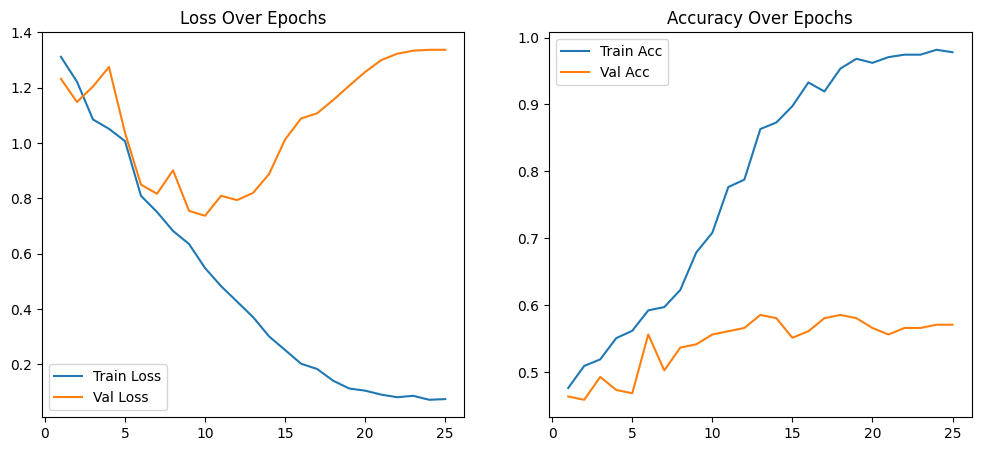

In [17]:
# Config file for the IMDB sentiment analysis project
config_file = "configs/config_gpt2.yaml"
config = IMDBConfig.from_yaml(config_file)

# Set number of epochs and patience for quick testing
config.epochs = 25
config.patience = 25 # NO early stopping for now

# Create an instance of a TrainerHighLevel with a toy dataset
trainer = TrainerHighLevel(
                           config=config,
                           run_name="config_gpt2",
                           config_file=None, 
                           data_limit=1024,
                           model_class=IMDBModelLPPackedSeq,
                           device='auto'
                           )

# Fit the model using the trainer
trainer.fit()

# Plot the training and validation loss curves
trainer.plot_training_curves()

🚀 Using hardware accelerator: cuda:0


/usr/local/lib/python3.12/dist-packages/pytorch_lightning/loops/fit_loop.py:321: The number of training batches (40) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Epoch   1 | Train Loss: 0.8637 | Train Acc: 0.5069 | Val Loss: 0.7470 | Val Acc: 0.5398
Epoch   2 | Train Loss: 0.7146 | Train Acc: 0.5508 | Val Loss: 0.6660 | Val Acc: 0.5924
Epoch   3 | Train Loss: 0.6365 | Train Acc: 0.6340 | Val Loss: 0.6208 | Val Acc: 0.6554
Epoch   4 | Train Loss: 0.5188 | Train Acc: 0.7427 | Val Loss: 0.5944 | Val Acc: 0.6984
Epoch   5 | Train Loss: 0.3459 | Train Acc: 0.8519 | Val Loss: 0.4887 | Val Acc: 0.8340
Epoch   6 | Train Loss: 0.2252 | Train Acc: 0.9125 | Val Loss: 0.5449 | Val Acc: 0.7676
Epoch   7 | Train Loss: 0.1599 | Train Acc: 0.9452 | Val Loss: 0.5237 | Val Acc: 0.7988
Epoch   8 | Train Loss: 0.1169 | Train Acc: 0.9613 | Val Loss: 0.6137 | Val Acc: 0.8070

🛑 Early Stopping triggered at epoch 8

✅ Training finished. Loading best model State

🏆 Best Model Metrics (from Epoch 5):
├─ Train Loss: 0.3459
├─ Train Acc:  0.8519
├─ Val Loss:   0.4887
└─ Val Acc:    0.8340


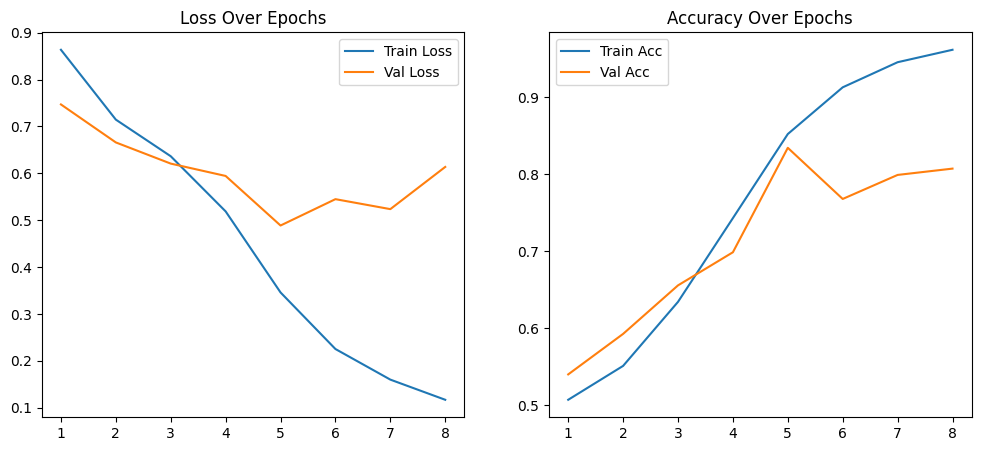

In [18]:
# Config file for the IMDB sentiment analysis project
config_file = "configs/config_gpt2.yaml"
config = IMDBConfig.from_yaml(config_file)

# Create an instance of a TrainerHighLevel with a toy dataset
trainer = TrainerHighLevel(
                           config=config,
                           run_name="config_gpt2",
                           config_file=None, 
                           data_limit=None, # Set to None for full dataset
                           model_class=IMDBModelLPPackedSeq,
                           device='auto'
                           )

# Fit the model using the trainer
trainer.fit()

# Plot the training and validation loss curves
trainer.plot_training_curves()

## 02 Using BERT tokenizer

In [11]:
# Config file for the IMDB sentiment analysis project
config_file = "configs/config_bert.yaml"
config = IMDBConfig.from_yaml(config_file)

# Create IMDBData instance with the specified configuration
data = IMDBData(config=config, data_limit=None, with_padding=True)

DEBUG:imdb.dataset:===DATASET LOADED===
DEBUG:imdb.dataset:Dataset splits: dict_keys(['train', 'test', 'unsupervised'])
DEBUG:imdb.dataset:Number of training samples (original dataset): 25000
DEBUG:imdb.dataset:Number of test samples (original dataset): 25000
DEBUG:imdb.dataset:===DATASET SPLIT===
DEBUG:imdb.dataset:Train/val split ratios: 0.8/0.2
DEBUG:imdb.dataset:Number of training samples (after split): 20000
DEBUG:imdb.dataset:Number of validation samples (after split): 5000
DEBUG:imdb.dataset:===LOADING PRETRAINED TOKENIZER (bert-base-uncased)===
DEBUG:imdb.dataset:Using local tokenizer found at: datasets/tokenizers/bert-base-uncased/tokenizer.json
DEBUG:imdb.dataset:Tokenizer 'bert-base-uncased' loaded. Vocabulary size: 30522
DEBUG:imdb.dataset:BERT vocabulary size: 30522
DEBUG:imdb.dataset:[PAD] token ID: 0
DEBUG:imdb.dataset:[UNK] token ID: 100
DEBUG:imdb.dataset:Token at ID 0: [PAD]


🚀 Using hardware accelerator: cuda:0
Epoch   2 | Train Loss: 0.9548 | Train Acc: 0.4750 | Val Loss: 0.8392 | Val Acc: 0.5024
Epoch   4 | Train Loss: 0.8630 | Train Acc: 0.5238 | Val Loss: 0.9023 | Val Acc: 0.4732
Epoch   6 | Train Loss: 0.7403 | Train Acc: 0.5495 | Val Loss: 0.7648 | Val Acc: 0.5268
Epoch   8 | Train Loss: 0.6435 | Train Acc: 0.6337 | Val Loss: 0.7438 | Val Acc: 0.5561
Epoch  10 | Train Loss: 0.5493 | Train Acc: 0.7241 | Val Loss: 0.8014 | Val Acc: 0.5415
Epoch  12 | Train Loss: 0.4603 | Train Acc: 0.7961 | Val Loss: 0.8207 | Val Acc: 0.5707
Epoch  14 | Train Loss: 0.3769 | Train Acc: 0.8266 | Val Loss: 1.0491 | Val Acc: 0.5659
Epoch  16 | Train Loss: 0.2838 | Train Acc: 0.8852 | Val Loss: 0.9962 | Val Acc: 0.5902
Epoch  18 | Train Loss: 0.2519 | Train Acc: 0.8950 | Val Loss: 1.0534 | Val Acc: 0.5951
Epoch  20 | Train Loss: 0.1992 | Train Acc: 0.9255 | Val Loss: 1.1560 | Val Acc: 0.5659
Epoch  22 | Train Loss: 0.2025 | Train Acc: 0.9109 | Val Loss: 1.1949 | Val Acc: 0.

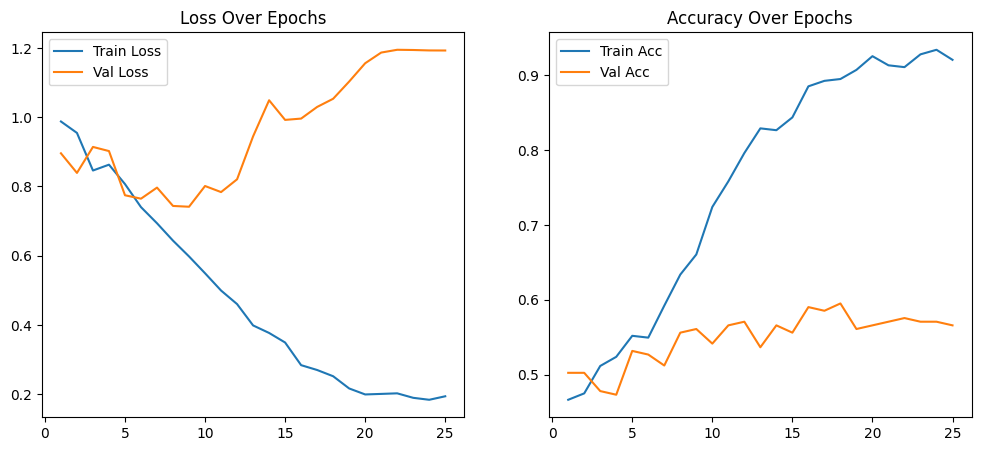

In [19]:
# Config file for the IMDB sentiment analysis project
config_file = "configs/config_bert.yaml"
config = IMDBConfig.from_yaml(config_file)

# Set number of epochs and patience for quick testing
config.epochs = 25
config.patience = 25 # NO early stopping for now

# Create an instance of a TrainerHighLevel with a toy dataset
trainer = TrainerHighLevel(
                           config=config,
                           run_name="config_bert",
                           config_file=None, 
                           data_limit=1024,
                           model_class=IMDBModelLPPackedSeq,
                           device='auto'
                           )

# Fit the model using the trainer
trainer.fit()

# Plot the training and validation loss curves
trainer.plot_training_curves()

🚀 Using hardware accelerator: cuda:0
Epoch   1 | Train Loss: 0.9112 | Train Acc: 0.4954 | Val Loss: 0.7763 | Val Acc: 0.5060
Epoch   2 | Train Loss: 0.7491 | Train Acc: 0.5244 | Val Loss: 0.6876 | Val Acc: 0.5530
Epoch   3 | Train Loss: 0.6793 | Train Acc: 0.5724 | Val Loss: 0.6651 | Val Acc: 0.6014
Epoch   4 | Train Loss: 0.6292 | Train Acc: 0.6442 | Val Loss: 0.6204 | Val Acc: 0.6576
Epoch   5 | Train Loss: 0.5222 | Train Acc: 0.7402 | Val Loss: 0.6066 | Val Acc: 0.7004
Epoch   6 | Train Loss: 0.3962 | Train Acc: 0.8239 | Val Loss: 0.5050 | Val Acc: 0.7870
Epoch   7 | Train Loss: 0.3458 | Train Acc: 0.8594 | Val Loss: 0.5753 | Val Acc: 0.7476
Epoch   8 | Train Loss: 0.2511 | Train Acc: 0.9040 | Val Loss: 0.4985 | Val Acc: 0.8204
Epoch   9 | Train Loss: 0.2266 | Train Acc: 0.9146 | Val Loss: 0.6356 | Val Acc: 0.7822
Epoch  10 | Train Loss: 0.1597 | Train Acc: 0.9399 | Val Loss: 0.6292 | Val Acc: 0.8298
Epoch  11 | Train Loss: 0.1633 | Train Acc: 0.9416 | Val Loss: 0.6065 | Val Acc: 0.

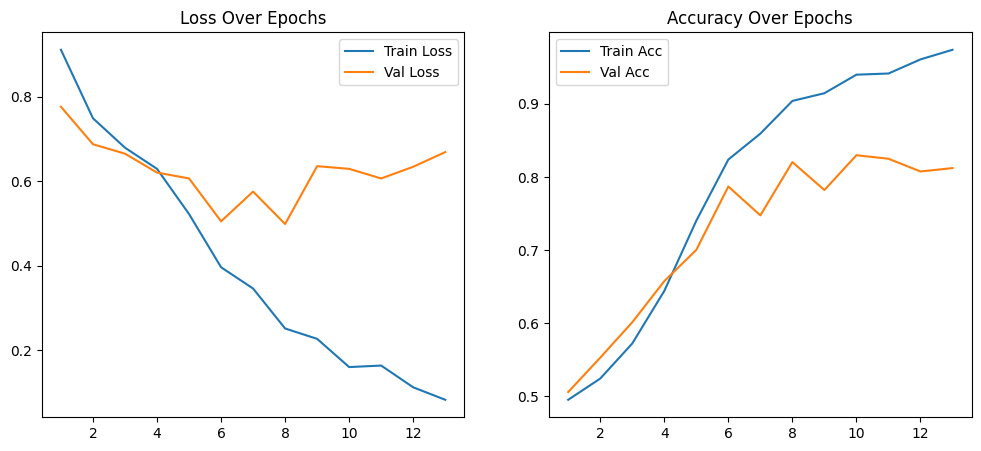

In [22]:
# Config file for the IMDB sentiment analysis project
config_file = "configs/config_bert.yaml"
config = IMDBConfig.from_yaml(config_file)

# Change the number of epochs and patience 
config.epochs = 25
config.patience = 5 # Increase patience for early stopping

# Create an instance of a TrainerHighLevel with a toy dataset
trainer = TrainerHighLevel(
                           config=config,
                           run_name="config_bert",
                           config_file=None, 
                           data_limit=None, # Use the full dataset
                           model_class=IMDBModelLPPackedSeq,
                           device='auto',
                           print_every_n_epochs=1
                           )

# Fit the model using the trainer
trainer.fit()

# Plot the training and validation loss curves
trainer.plot_training_curves()

## 03 Using GPT2 tokenizer: 3 runs with different seeds

In [6]:
# Config file for the IMDB sentiment analysis project
config_file = "configs/config_gpt2.yaml"
config = IMDBConfig.from_yaml(config_file)

# Create IMDBData instance with the specified configuration
data = IMDBData(config=config, data_limit=None, with_padding=True)

In [9]:
for seed in [42, 43, 44]:

    # Create an instance of a TrainerHighLevel with a toy dataset
    trainer = TrainerHighLevel(
                            config=config,
                            run_name=f"config_gpt2_{seed}",
                            config_file=None, 
                            data_limit=None, # Set to None for full dataset
                            model_class=IMDBModelLPPackedSeq,
                            device='auto',
                            trainer_seed=seed,
                            print_every_n_epochs=1,
                            )

    # Fit the model using the trainer
    print(f"\n=== Training with seed {seed} ===")
    trainer.fit()

INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.



=== Training with seed 42 ===
🚀 Using hardware accelerator: cuda:0


INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:Loading `train_dataloader` to estimate number of stepping batches.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/loops/fit_loop.py:321: The number of training batches (40) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved. New best score: 0.755


Epoch   1 | Train Loss: 0.8941 | Train Acc: 0.5063 | Val Loss: 0.7546 | Val Acc: 0.5334


INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved by 0.085 >= min_delta = 0.0. New best score: 0.669


...

Epoch   3 | Train Loss: 0.6476 | Train Acc: 0.6215 | Val Loss: 0.6266 | Val Acc: 0.6578
Epoch   4 | Train Loss: 0.5229 | Train Acc: 0.7449 | Val Loss: 0.6692 | Val Acc: 0.6866
Epoch   5 | Train Loss: 0.3759 | Train Acc: 0.8332 | Val Loss: 0.6566 | Val Acc: 0.7238


INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved by 0.054 >= min_delta = 0.0. New best score: 0.573


Epoch   6 | Train Loss: 0.2352 | Train Acc: 0.9079 | Val Loss: 0.5726 | Val Acc: 0.7720
Epoch   7 | Train Loss: 0.1577 | Train Acc: 0.9429 | Val Loss: 0.5941 | Val Acc: 0.7948
Epoch   8 | Train Loss: 0.1001 | Train Acc: 0.9662 | Val Loss: 0.6617 | Val Acc: 0.7830


INFO:pytorch_lightning.callbacks.early_stopping:Monitored metric val_loss did not improve in the last 3 records. Best score: 0.573. Signaling Trainer to stop.


Epoch   9 | Train Loss: 0.0701 | Train Acc: 0.9780 | Val Loss: 0.7427 | Val Acc: 0.8076

🛑 Early Stopping triggered at epoch 9

✅ Training finished. Loading best model State

🏆 Best Model Metrics (from Epoch 6):
├─ Train Loss: 0.2352
├─ Train Acc:  0.9079
├─ Val Loss:   0.5726
└─ Val Acc:    0.7720


## 04 Using BERT tokenizer: 3 runs with different seeds

In [ ]:
# Config file for the IMDB sentiment analysis project
config_file = "configs/config_bert.yaml"
config = IMDBConfig.from_yaml(config_file)

# Create IMDBData instance with the specified configuration
data = IMDBData(config=config, data_limit=None, with_padding=True)

In [ ]:
for seed in [42, 43, 44]:

    # Create an instance of a TrainerHighLevel with a toy dataset
    trainer = TrainerHighLevel(
                            config=config,
                            run_name=f"config_bert_{seed}",
                            config_file=None, 
                            data_limit=None, # Use the full dataset
                            model_class=IMDBModelLPPackedSeq,
                            device='auto',
                            print_every_n_epochs=1,
                            trainer_seed=seed
                            )

    # Fit the model using the trainer
    print(f"\n=== Training with seed {seed} ===")
    trainer.fit()